<div style="background: linear-gradient(135deg, #1e293b 0%, #0f172a 100%); padding: 30px; border-radius: 8px; margin-bottom: 25px; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1);">
    <h1 style="color: #f8fafc; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: 700; margin: 0; font-size: 2.2em; letter-spacing: -0.5px;"> Estudio deberes PISA 2012-2022 🌍
</h1>
    <p style="color: #94a3b8; font-family: 'Segoe UI', sans-serif; margin: 8px 0 0 0; font-size: 1.1em;"> Estudio del factor 'Deberes' en los informes PISA
 </p>
    
</div>

# 📋 Descripción

Este cuaderno analiza qué indicadores relacionados con los deberes y los hábitos de estudio presentan mayor importancia predictiva para la media de Matemáticas de PISA 2022.

La nota esta calculada para los estratos del pais , los indicadores de deberes se agregan a esa misma unidad antes de unirlos y entrenar el modelo. El análisis describe asociaciones predictivas entre estratos, no efectos individuales ni relaciones causales.


<div style="
  background: linear-gradient(135deg, rgba(128, 128, 128, 0.25) 0%, rgba(64, 64, 64, 0.15) 100%);
  backdrop-filter: blur(4px);
  -webkit-backdrop-filter: blur(4px);
  border-left: 5px solid rgba(128, 128, 128, 0.6);
  padding: 16px;
  border-radius: 8px;
  color: inherit;
  margin: 20px 0;
">
  <strong style="display: block; margin-bottom: 6px; font-size: 1.1em;">
    💡 Uso de datos de 2022
  </strong>
    Dado que se esta realizando un análisis de la edición de PISA 2022, se usaran para esta parte las notas de matemáticas, correspondientes a la competencia específica de esta edición. Una vez completado el análisis de factores importantes para este año, se realizara una busqueda y adaptación de los indices correspondietes en los otros años
</div>


## Selección de variables

**Estudiantes (`pisa2022_estudiantes.parquet`)**

| Código de variable | Descripción y uso en el proyecto |
| :--- | :--- |
| `ST296Q01JA` | Tiempo dedicado a los deberes de Matemáticas; se convierte de categoría a horas aproximadas y se agrega por estrato. |
| `ST296Q04JA` | Tiempo total diario dedicado a los deberes; se convierte de categoría a horas aproximadas y se agrega por estrato. |
| `STUDYHMW` | Índice relacionado con la frecuencia de estudio y los deberes; se agrega por estrato. |
| `ST307Q07JA` | Indicador de dejar los deberes cuando son demasiado largos; se agrega por estrato. |
| `ST309Q05JA` | Indicador de revisar cuidadosamente los deberes antes de entregarlos; se agrega por estrato. |
| `W_FSTUWT` | Peso final del alumno, usado para agregar los indicadores de estudiantes por `CNT` y `STRATUM`. |
| `CNT`, `STRATUM` | Identificadores de país y estrato que permiten agregar y unir las tablas. |

**Colegios (`pisa2022_colegios.parquet`)**

| Código de variable | Descripción y uso en el proyecto |
| :--- | :--- |
| `SC212Q01JA` | Disponibilidad de salas donde el alumnado puede hacer los deberes. |
| `SC212Q02JA` | Disponibilidad de personal del centro que ayuda con los deberes. |
| `SC212Q03JA` | Disponibilidad de ayuda por otros alumnos. |
| `SENWT` | Peso del colegio, usado para agregar sus indicadores dentro de `CNT` y `STRATUM`. |
| `CNT`, `STRATUM`, `CNTSCHID` | Identificadores de país, estrato y colegio, utilizados para comprobar la correspondencia entre estudiantes y centros. |

**Variable objetivo ya procesada (`medias_asignaturas_anual`)**

| Variable / fichero | Descripción y uso en este cuaderno |
| :--- | :--- |
| `media_math_estrato` | Media de Matemáticas por país y estrato, calculada previamente a partir de los valores plausibles. Aquí solo se lee desde Parquet; no se recalcula ni se vuelve a ponderar. |
| `pisa22_medias_math_estrato.parquet` | Fichero de `data/intermediate/medias_asignaturas_anual` que contiene `CNT`, `STRATUM` y `media_math_estrato`. |

**Tiempos de respuesta (no disponibles en los Parquet actuales)**

| Variables | Situación en los datos actuales |
| :--- | :--- |
| `ST296_TT`, `ST307_TT`, `ST309_TT` | No están incluidas en los Parquet de estudiantes utilizados; por ello, no se aplica el filtro de *rapid responders* del flujo anterior con SAS. |

## Carga de los datos 

In [9]:
import gc
import sys
import os
from pathlib import Path

#Indicamos el workspace principal (dos niveles atrás)
sys.path.append(os.path.abspath('../../'))

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from src.utils_pisa import *

establecer_semilla(42)
pd.set_option('display.float_format', lambda valor: f'{valor:.2f}')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Semillas del proyecto establecidas con éxito (seed=42).


In [208]:
import sys
from pathlib import Path

# Subir dos niveles en la estructura de carpetas (desde tu notebook hasta la raíz 'TFM Data Science PISA')
raiz_proyecto = Path.cwd().parents[1]

if str(raiz_proyecto) not in sys.path:
    sys.path.append(str(raiz_proyecto))

In [ ]:
# Generamos las rutas de los ficheros de datos
ruta_datos_raw = Path('../../data/raw')
ruta_datos_intermedios = Path('../../data/intermediate')
ruta_datos_procesados = Path('../../data/processed')

ruta_medias_asignaturas = ruta_datos_intermedios/'medias_asignaturas_anual'

ruta_estudiantes = ruta_datos_raw / 'pisa2022_estudiantes.parquet'
ruta_colegios = ruta_datos_raw / 'pisa2022_colegios.parquet'

ruta_media_estratos = ruta_medias_asignaturas / 'pisa_medias_asignaturas_estrato_anual.parquet'



In [11]:
# Almacenamos las variables de interes para el análisis de deberes
claves_estrato = ['CNT', 'STRATUM']

indicadores_alumno = [
    'ST296Q01JA', 'ST296Q04JA', 'STUDYHMW', 'ST307Q07JA', 'ST309Q05JA'
]

indicadores_colegio = ['SC212Q01JA', 'SC212Q02JA', 'SC212Q03JA']

columnas_estudiantes = claves_estrato + indicadores_alumno + ['CNTSCHID','W_FSTUWT', 'SENWT']

columnas_colegios = claves_estrato + ['CNTSCHID'] + indicadores_colegio

In [375]:
# Se leen únicamente las columnas necesarias relacionadas con los deberes
df_estudiantes = pd.read_parquet(ruta_estudiantes, columns=columnas_estudiantes)
df_colegios = pd.read_parquet(ruta_colegios, columns=columnas_colegios)
df_media_matematicas = pd.read_parquet(ruta_datos_procesados/'pisa_medias_asignaturas_estrato_anual.parquet',
                                       columns=claves_estrato+['media_math_estrato','year'])

df_media_matematicas=df_media_matematicas[df_media_matematicas['year']==2022]




columnas_esperadas_nota = claves_estrato + ['media_math_estrato']

print(f'Estudiantes: {len(df_estudiantes):,}')
print(f'Colegios: {len(df_colegios):,}')
print(f'Número de estratos: {len(df_media_matematicas):,}')
df_media_matematicas.head()


Estudiantes: 268,610
Colegios: 10,131
Número de estratos: 422


,CNT,STRATUM,media_math_estrato,year
0,USA,USA08,476.10,2022
1,USA,USA07,539.40,2022
2,USA,USA06,454.64,2022
3,USA,USA05,476.43,2022
4,USA,USA04,469.99,2022


## Agregación de los indicadores de deberes a país-estrato

La media de Matemáticas por `CNT` y `STRATUM` ya está calculada y se carga directamente desde `pisa22_medias_math_estrato.parquet`; no se vuelven a procesar aquí los valores plausibles ni se recalcula la nota. La función `promedio_ponderado_indicadores_agrupado` se utiliza exclusivamente para resumir los indicadores de deberes a esa misma unidad: respuestas de estudiantes con `W_FSTUWT` y respuestas de colegios con `SENWT`.


In [376]:
# Recodificación de las categorías de tiempo : <30m, 30m-1h, 1-2h, 2-3h, 3-4h, >4h.
mapeo_horas = {1: 0.25, 
               2: 0.75, 
               3: 1.50, 
               4: 2.50, 
               5: 3.50, 
               6: 4.50}

for columna in ['ST296Q01JA', 'ST296Q04JA']:
    df_estudiantes[columna] = df_estudiantes[columna].map(mapeo_horas)


In [377]:
# Calculamos el promedio ponderado con el peso de estudiante de los indices a evaluar de los estudiantes
df_indicadores_alumno_2022_strat = promedio_ponderado_indicadores_agrupado(
    df_estudiantes[claves_estrato + indicadores_alumno+['W_FSTUWT']],
    indicadores_alumno,
    'W_FSTUWT',
    claves_estrato
)



# Calculamos el promedio ponderado con el peso de estudiante de los indices a evaluar de los estudiantes
df_indicadores_alumno_2022_cnt = promedio_ponderado_indicadores_agrupado(
    df_estudiantes[['CNT'] + indicadores_alumno+['W_FSTUWT']],
    indicadores_alumno,
    'W_FSTUWT',
    claves_agrupacion=['CNT']
)


display(df_indicadores_alumno_2022_strat.head())
display(df_indicadores_alumno_2022_cnt.head())



,CNT,STRATUM,ST296Q01JA,ST296Q04JA,STUDYHMW,ST307Q07JA,ST309Q05JA
0,AUS,AUS04,0.75,1.41,3.84,2.93,3.15
1,AUS,AUS06,0.88,1.74,4.95,2.89,3.16
2,AUS,AUS08,0.74,1.38,3.33,2.98,3.06
3,AUS,AUS05,0.73,1.24,3.38,2.99,3.10
4,AUS,AUS14,0.59,1.33,3.43,3.05,3.09


,CNT,ST296Q01JA,ST296Q04JA,STUDYHMW,ST307Q07JA,ST309Q05JA
0,AUS,0.70,1.37,3.64,3.00,3.01
1,AUT,0.61,1.30,5.36,2.44,2.89
2,BEL,0.74,1.63,5.29,2.80,3.14
3,CAN,0.83,1.67,4.57,2.90,3.24
4,CHL,0.99,1.63,4.36,2.61,3.61


In [435]:
#Pasamos la columna de pesos de estudiante W_FSTUWT a la de colegios pare poder tener la ponderación 
claves_colegio = ['CNT', 'STRATUM', 'CNTSCHID']

pesos_estudiantes_colegio = (
    df_estudiantes
    .groupby(claves_colegio, as_index=False)
    .agg(W_FSTUWT=('W_FSTUWT', 'sum'))
)

df_colegios = df_colegios.merge(
    pesos_estudiantes_colegio,
    on=claves_colegio,
    how='left',
    validate='one_to_one',
)

In [436]:

df_indicadores_colegio_2022_strat = promedio_ponderado_indicadores_agrupado(
    df_colegios,
    indicadores_colegio,
    'W_FSTUWT',
    claves_estrato
)

df_indicadores_colegio_2022_cnt = promedio_ponderado_indicadores_agrupado(
    df_colegios,
    indicadores_colegio,
    'W_FSTUWT',
    claves_agrupacion=['CNT']
)


display(df_indicadores_colegio_2022_strat.head())
display(df_indicadores_colegio_2022_cnt.head())


,CNT,STRATUM,SC212Q01JA,SC212Q02JA,SC212Q03JA
0,AUS,AUS11,1.15,1.06,1.56
1,AUS,AUS15,1.26,1.17,1.63
2,AUS,AUS18,1.08,1.00,1.50
3,AUS,AUS03,1.01,1.01,1.22
4,AUS,AUS12,1.03,1.00,1.46


,CNT,SC212Q01JA,SC212Q02JA,SC212Q03JA
0,AUS,1.15,1.11,1.62
1,AUT,1.26,1.64,1.37
2,BEL,1.12,1.37,1.72
3,CAN,1.10,1.07,1.29
4,CHL,1.21,1.52,1.49


In [ ]:
# Peso poblacional del estrato para ponderar su contribucion al modelo

# Agregamos el peso de senado 
peso_senado_alumno = (
    df_estudiantes[claves_estrato+['SENWT']]
    .groupby(claves_estrato, as_index=False)
    .agg(SENWT=('SENWT', 'mean')) # Usamos 'mean' para no distorsionar la escala del peso de senado por estrato
)

df_analisis_deberes_2022_strat = (
    df_media_matematicas
    .merge(df_indicadores_alumno_2022_strat, on=claves_estrato, how='left', validate='one_to_one')
    .merge(df_indicadores_colegio_2022_strat, on=claves_estrato, how='left', validate='one_to_one')
    .merge(peso_senado_alumno, on=claves_estrato, how='left', validate='one_to_one')
)

print(f"Filas de analisis-estratos: {len(df_analisis_deberes_2022_strat):,}")
print(f"Columnas de predictores: {len(indicadores_alumno) + len(indicadores_colegio)}")
df_analisis_deberes_2022_strat


Filas de analisis-estratos: 422
Columnas de predictores: 8


,CNT,STRATUM,media_math_estrato,ST296Q01JA,ST296Q04JA,STUDYHMW,ST307Q07JA,ST309Q05JA,SC212Q01JA,SC212Q02JA,SC212Q03JA,SENWT
0,AUS,AUS01,508.70,1.63,2.56,3.81,3.05,3.06,1.11,1.00,1.19,0.12
1,AUS,AUS02,479.18,1.74,2.83,3.63,3.09,3.06,1.16,1.10,1.48,0.10
2,AUS,AUS03,540.42,1.81,3.01,4.67,2.85,3.27,1.01,1.01,1.22,0.07
3,AUS,AUS04,495.91,1.82,2.64,3.84,2.93,3.15,1.16,1.15,1.54,0.42
4,AUS,AUS05,478.73,1.75,2.40,3.38,2.99,3.10,1.25,1.17,1.73,0.52
...,...,...,...,...,...,...,...,...,...,...,...,...
417,USA,USA04,469.99,1.60,2.60,4.48,NaN,NaN,1.12,1.09,1.28,1.05
418,USA,USA05,476.43,2.02,3.05,5.42,NaN,NaN,1.00,1.00,1.00,1.88
419,USA,USA06,454.64,1.59,2.55,4.21,NaN,NaN,1.18,1.07,1.29,0.99
420,USA,USA07,539.40,1.80,3.40,6.00,NaN,NaN,NaN,NaN,NaN,3.12


## Modelo de regresión basado en árboles

El modelo recibe una fila por país-estrato. Su variable objetivo es `media_math_estrato`, recuperada del Parquet de medias ya calculadas; los predictores son los indicadores de deberes agregados a ese nivel. La suma de `W_FSTUWT` por estrato pondera su contribución al ajuste. Las importancias describen asociaciones predictivas entre estratos, no efectos causales ni relaciones a nivel individual.

In [381]:
features = df_analisis_deberes_2022_strat[indicadores_alumno + indicadores_colegio]
target = df_analisis_deberes_2022_strat['media_math_estrato']
pesos = df_analisis_deberes_2022_strat['SENWT']

modelo_deberes = xgb.XGBRegressor(
    n_estimators=100,
    tree_method='hist',
    importance_type='gain',
)
modelo_deberes.fit(features, target, sample_weight=pesos)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type='gain', interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [382]:
tabla_importancia = pd.DataFrame({
    'Indicador': features.columns,
    'Importancia relativa (%)': modelo_deberes.feature_importances_ * 100,
}).sort_values('Importancia relativa (%)', ascending=False).reset_index(drop=True)

tabla_importancia


,Indicador,Importancia relativa (%)
0,STUDYHMW,17.92
1,ST309Q05JA,15.07
2,ST296Q01JA,14.96
3,ST296Q04JA,14.44
4,SC212Q01JA,11.81
5,SC212Q03JA,11.57
6,ST307Q07JA,7.96
7,SC212Q02JA,6.26


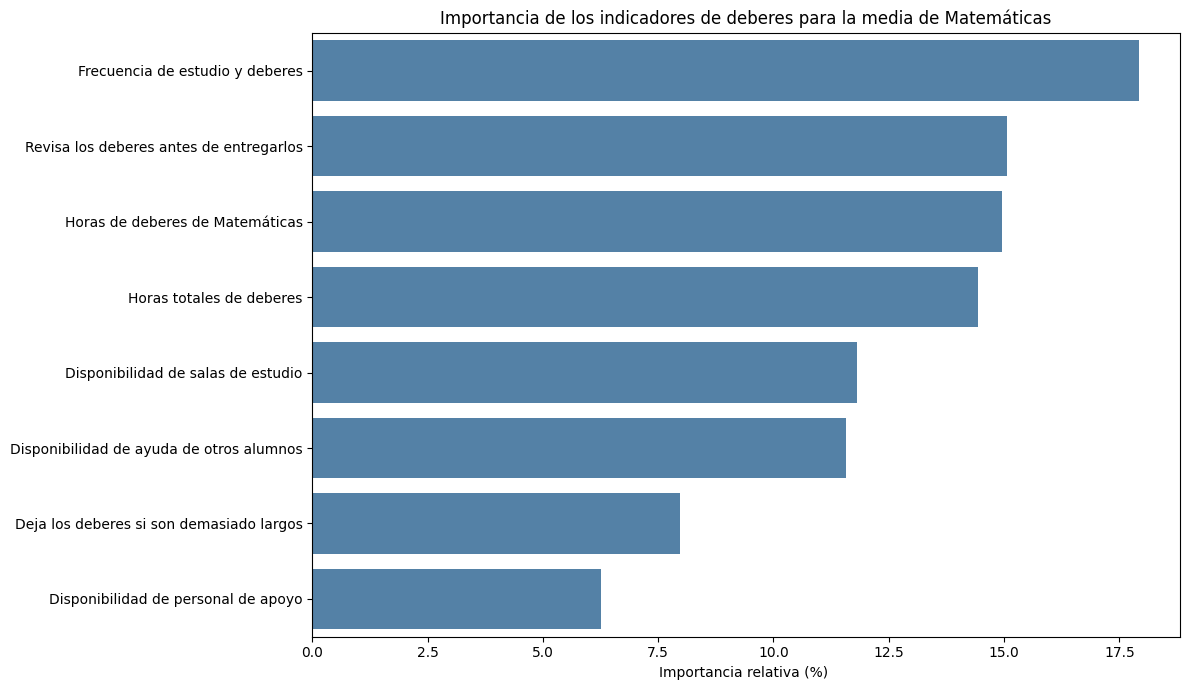

In [383]:
# Diccionario de traducción de los indicadores
diccionario_indicadores = {
    'ST296Q01JA': 'Horas de deberes de Matemáticas',
    'ST296Q04JA': 'Horas totales de deberes',
    'STUDYHMW': 'Frecuencia de estudio y deberes',
    'ST307Q07JA': 'Deja los deberes si son demasiado largos',
    'ST309Q05JA': 'Revisa los deberes antes de entregarlos',
    'SC212Q01JA': 'Disponibilidad de salas de estudio',
    'SC212Q02JA': 'Disponibilidad de personal de apoyo',
    'SC212Q03JA': 'Disponibilidad de ayuda de otros alumnos',
}

tabla_importancia_traducida = tabla_importancia.copy()
tabla_importancia_traducida['Indicador'] = (
    tabla_importancia_traducida['Indicador'].map(diccionario_indicadores)
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=tabla_importancia_traducida,
    x='Importancia relativa (%)',
    y='Indicador',
    color='steelblue',
)
plt.title('Importancia de los indicadores de deberes para la media de Matemáticas')
plt.xlabel('Importancia relativa (%) ')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Nota sobre la unidad de análisis

La nota no es individual: cada observación representa un país y un estrato. Por ello, las importancias deben interpretarse como relaciones entre medias de indicadores de deberes y medias de Matemáticas agregadas, no como el efecto de los deberes en la nota de cada alumno.


<div style="
  background: linear-gradient(135deg, rgba(128, 128, 128, 0.25) 0%, rgba(64, 64, 64, 0.15) 100%);
  backdrop-filter: blur(4px);
  -webkit-backdrop-filter: blur(4px);
  border-left: 5px solid rgba(128, 128, 128, 0.6);
  padding: 16px;
  border-radius: 8px;
  color: inherit;
  margin: 20px 0;
">
  <strong style="display: block; margin-bottom: 6px; font-size: 1.1em;">
    ⚠️ Equivalencia de datos en años anteriores 
  </strong>

  Todas las <i>feature importance</i> destacadas para 2022 no encuentran su equivalente directo en años anteriores o  no existe un indice al que se podría asemejar. Es por ello que se utilizaran <b>únicamente</b> aquellos indices de los seleccionados para 2022 cuya información pueda ser replicada de alguna forma en los otros años
</div>




# Preparacion de los datos de 2022

In [384]:
#Datos ponderados de 2022 agregados por estratos 

# Mapeo de variables con las que nos quedamos del dataframe utilizado para el modelo XGBOOST
mapa_variables = {
    'ST296Q04JA': 'tiempo_deberes_totales_diarios',
    'SC212Q02JA': 'dispone_personal_apoyo'
}
# Definimos las columnas a mantener
columnas_a_mantener_strat = claves_estrato + list(mapa_variables.keys())

# Filtramos la tabla maestra (df_final) creando una copia limpia
df_base_2022_strat = df_analisis_deberes_2022_strat[columnas_a_mantener_strat].copy()

# Aplicamos los nombres semánticos universales
df_base_2022_strat.rename(columns=mapa_variables, inplace=True)

# Añadimos la variable del año
df_base_2022_strat['year'] = 2022

df_base_2022_strat=df_base_2022_strat[claves_estrato+['year','tiempo_deberes_totales_diarios','dispone_personal_apoyo']]


In [385]:
#Datos ponderados de 2022 agregados por pais 

df_analisis_deberes_2022_cnt = (
    df_indicadores_alumno_2022_cnt
    .merge(df_indicadores_colegio_2022_cnt, on=['CNT'], how='left', validate='one_to_one')
)

columnas_a_mantener_cnt = ['CNT'] + list(mapa_variables.keys())

df_base_2022_cnt = df_analisis_deberes_2022_cnt[columnas_a_mantener_cnt].copy()

# Aplicamos los nombres semánticos universales
df_base_2022_cnt.rename(columns=mapa_variables, inplace=True)

# Añadimos la variable del año
df_base_2022_cnt['year'] = 2022
df_base_2022_cnt=df_base_2022_cnt[['CNT']+['year','tiempo_deberes_totales_diarios','dispone_personal_apoyo']]




In [386]:
df_base_2022_strat.head()

,CNT,STRATUM,year,tiempo_deberes_totales_diarios,dispone_personal_apoyo
0,AUS,AUS01,2022,2.56,1.00
1,AUS,AUS02,2022,2.83,1.10
2,AUS,AUS03,2022,3.01,1.01
3,AUS,AUS04,2022,2.64,1.15
4,AUS,AUS05,2022,2.40,1.17


In [387]:
df_base_2022_cnt.head()

,CNT,year,tiempo_deberes_totales_diarios,dispone_personal_apoyo
0,AUS,2022,1.37,1.11
1,AUT,2022,1.30,1.64
2,BEL,2022,1.63,1.37
3,CAN,2022,1.67,1.07
4,CHL,2022,1.63,1.52


# Obtención de datos equivalentesPISA 2012

### Diccionario de Equivalencias (PISA 2022 ➜ PISA 2012)

| Descripcion | Variable PISA 2022 | Variable PISA 2012 | Transformación / Lógica Condicional en Pandas |
| :--- | :--- | :--- | :--- |
| `tiempo_deberes_totales_diarios` | `ST296Q04JA` | `ST57Q01`, `ST57Q02`, `ST57Q05` | `(ST57Q01 + ST57Q02 + ST57Q05) / 5` |
| `dispone_personal_apoyo` | `SC212Q02JA` | `SC20Q01` + `SC21Q05` *(Proxy)* | **1** si `SC20Q01 == 1` Y `SC21Q05` ∈ `{2, 3}`. <br>**0** en caso contrario. |

### Construcción del equivalente Tiempo Total de Deberes en PISA 2012

En PISA 2012, el cuestionario dividía el tiempo de estudio semanal fuera de clase en varios ítems independientes. Para obtener una métrica armonizada y realista del tiempo total diario dedicado a los deberes (comparable con las ediciones posteriores), se agrupan las distintas modalidades de deberes y ayuda en el entorno familiar:

* **`ST57Q01`**: Trabajo autónomo / Deberes (*Homework*)
* **`ST57Q02`**: Deberes guiados o supervisados (*Guided Homework*)
* **`ST57Q05`**: Estudio o deberes con ayuda de los padres (*With Parent*)

**Regla de codificación:**
Se calcula la suma horizontal de las horas semanales reportadas en estas tres modalidades para capturar el volumen real de estudio en casa. Este total semanal se divide entre 5 (días lectivos) para estimar la carga diaria. Para evitar sesgos a la baja, la suma requiere un mínimo de una respuesta válida (`min_count=1`).

$$tiempo\_deberes\_totales\_diarios = \frac{ST57Q01 + ST57Q02 + ST57Q05}{5}$$


### Construcción del equivalente Apoyo Escolar en PISA 2012

Dada la ausencia estructural de la variable sobre apoyo para los deberes en 2012, obtenemos su equivalente mediante una transformación de las variables de refuerzo matemático del Cuestionario de Directores de 2012:

* **`SC20Q01`**: *"Additional maths lessons"* (1 = Sí, 2 = No)
* **`SC21Q05`**: *"Purpose of additional maths lessons"* (1 = Enrichment, 2 = Remedial, 3 = Both enrichment and remedial, 4 = Without differentiation)

**Regla de codificación:**
Se codificará con valor **1** (dispone de apoyo) a aquellos centros que ofrezcan clases adicionales de matemáticas enfocadas en el refuerzo compensatorio (*Remedial*) o en una modalidad mixta.

$$dispone\_personal\_apoyo =  \begin{cases}  1 & \text{si } SC20Q01 = 1 \text{ y } SC21Q05 \in \{2, 3\} \\  0 & \text{en otro caso}  \end{cases}$$

In [388]:
# Carga de variables disponibles en PISA 2012.
ruta_estudiantes_2012 = ruta_datos_raw / 'pisa2012_estudiantes.parquet'
ruta_colegios_2012 = ruta_datos_raw / 'pisa2012_colegios.parquet'


In [389]:
columnas_estudiantes_2012 = claves_estrato + [
    'CNTSCHID', 'W_FSTUWT', 'SENWT', 'ST57Q01','ST57Q02','ST57Q05'
]
columnas_colegios_2012 = claves_estrato + ['CNTSCHID','SC20Q01','SC21Q05']

In [390]:
#Cargamos los datos de estudiantes y de colegios correspondientes a 2012
df_estudiantes_2012 = pd.read_parquet(
    ruta_estudiantes_2012,
    columns=columnas_estudiantes_2012,
)
df_colegios_2012 = pd.read_parquet(
    ruta_colegios_2012,
    columns=columnas_colegios_2012,
)

La media para el indice ``ST57Q01`` es de 5, por lo que los datos se encuentran transformados a horas. Dividiremos la variable entre los 5 dias laborales

In [391]:
df_estudiantes_2012['tiempo_deberes_totales_diarios'] = df_estudiantes_2012[['ST57Q01', 'ST57Q02', 'ST57Q05']].sum(axis=1, min_count=1) / 5

indicadores_alumno_2012 = ['tiempo_deberes_totales_diarios']

# Indicadores de alumnos 2012 ponderados por estrato
df_indicadores_alumno_2012_strat = promedio_ponderado_indicadores_agrupado(
    df_estudiantes_2012[claves_estrato + indicadores_alumno_2012 + ['W_FSTUWT']],
    indicadores_alumno_2012,
    'W_FSTUWT',
    claves_estrato
)

# Indicadores de alumnos 2012 ponderados por país 
df_indicadores_alumno_2012_cnt = promedio_ponderado_indicadores_agrupado(
    df_estudiantes_2012[['CNT'] + indicadores_alumno_2012 + ['W_FSTUWT']],
    indicadores_alumno_2012,
    'W_FSTUWT',
    claves_agrupacion=['CNT']
)

In [392]:
df_indicadores_alumno_2012_strat.agg(['min','max'])

,CNT,STRATUM,tiempo_deberes_totales_diarios
min,AUS,AUS0101,0.00
max,USA,USA9797,3.37


In [393]:
display(df_indicadores_alumno_2012_strat.tail())
display(df_indicadores_alumno_2012_cnt.head())

,CNT,STRATUM,tiempo_deberes_totales_diarios
779,TUR,TUR0030,0.97
780,TUR,TUR0033,2.21
781,TUR,TUR0014,0.80
782,TUR,TUR0017,1.04
783,USA,USA9797,1.72


,CNT,tiempo_deberes_totales_diarios
0,AUS,1.61
1,AUT,1.29
2,BEL,1.34
3,CAN,1.48
4,CHE,1.15


In [394]:
#Obtenemos el indice de personal de apoyo mediante las variables de refuerzo matematico en 2012
condicion_refuerzo = (df_colegios_2012['SC20Q01'] == 1) & (df_colegios_2012['SC21Q05'].isin([2, 3]))

# Aplicamos np.where: si cumple la condición, es 1. Si no, es 0.
df_colegios_2012['dispone_personal_apoyo'] = np.where(condicion_refuerzo, 1, 0)

# Si el colegio dejó en blanco (NaN) la pregunta original, mantenemos el NaN
# para no inventarnos que "no" tienen el servicio si simplemente no respondieron la encuesta.

nulos_originales = df_colegios_2012['SC20Q01'].isna()
df_colegios_2012.loc[nulos_originales, 'dispone_personal_apoyo'] = np.nan

# borramos las columnas intermedias
df_colegios_2012.drop(columns=['SC20Q01', 'SC21Q05'], inplace=True)

In [395]:
df_colegios_2012.head()

,CNT,STRATUM,CNTSCHID,dispone_personal_apoyo
0,AUS,AUS0309,0000001,1.00
1,AUS,AUS0205,0000002,0.00
2,AUS,AUS0102,0000003,1.00
3,AUS,AUS0514,0000004,0.00
4,AUS,AUS0514,0000005,0.00


In [396]:

# Se utiliza el peso de alumnado asociado a cada centro, igual que en 2022.
claves_colegio_2012 = claves_estrato + ['CNTSCHID']

#Añadimos el peso de estudiante a colegios 
pesos_colegio_2012 = (
    df_estudiantes_2012
    .groupby(claves_colegio_2012, as_index=False)
    .agg(W_FSTUWT=('W_FSTUWT', 'sum'))
)

df_colegios_2012 = df_colegios_2012.merge(
    pesos_colegio_2012,
    on=claves_colegio_2012,
    how='left',
    validate='one_to_one',
)


In [397]:
indicadores_colegio_2012 = ['dispone_personal_apoyo']

#Agrupación de las variables ponderadas de colegio 2012 por estrato
df_indicadores_colegio_2012_strat = promedio_ponderado_indicadores_agrupado(
    df_colegios_2012[claves_estrato + indicadores_colegio_2012 + ['W_FSTUWT']],
    indicadores_colegio_2012,
    'W_FSTUWT',
    claves_estrato
)

#Agrupación de las variables ponderadas de colegio 2012 por pais 
df_indicadores_colegio_2012_cnt = promedio_ponderado_indicadores_agrupado(
    df_colegios_2012[claves_estrato + indicadores_colegio_2012 + ['W_FSTUWT']],
    indicadores_colegio_2012,
    'W_FSTUWT',
    claves_agrupacion=['CNT']
)


In [398]:
display(df_indicadores_colegio_2012_strat.head())
display(df_indicadores_colegio_2012_cnt.head())

,CNT,STRATUM,dispone_personal_apoyo
0,AUS,AUS0309,0.53
1,AUS,AUS0205,0.44
2,AUS,AUS0102,0.38
3,AUS,AUS0514,0.33
4,AUS,AUS0515,0.51


,CNT,dispone_personal_apoyo
0,AUS,0.50
1,AUT,0.44
2,BEL,0.56
3,CAN,0.58
4,CHE,0.47


In [399]:
#Agrupamos los resultados por estrato
df_base_2012_strat = (
    df_indicadores_alumno_2012_strat
    .merge(df_indicadores_colegio_2012_strat, on=claves_estrato, how='left', validate='one_to_one')
)
df_base_2012_strat['year'] = 2012

df_base_2012_strat = df_base_2012_strat[claves_estrato + ['year','tiempo_deberes_totales_diarios','dispone_personal_apoyo']]

In [400]:
#Agrupamos los resultados por estrato
df_base_2012_cnt = (
    df_indicadores_alumno_2012_cnt
    .merge(df_indicadores_colegio_2012_cnt, on=['CNT'], how='left', validate='one_to_one')
)
df_base_2012_cnt['year'] = 2012

df_base_2012_cnt = df_base_2012_cnt[['CNT'] + ['year','tiempo_deberes_totales_diarios','dispone_personal_apoyo']]

In [401]:
df_base_2012_strat.head()

,CNT,STRATUM,year,tiempo_deberes_totales_diarios,dispone_personal_apoyo
0,AUS,AUS0309,2012,2.17,0.53
1,AUS,AUS0205,2012,1.45,0.44
2,AUS,AUS0102,2012,1.50,0.38
3,AUS,AUS0514,2012,1.51,0.33
4,AUS,AUS0515,2012,2.19,0.51


In [402]:
df_base_2012_cnt.head()

,CNT,year,tiempo_deberes_totales_diarios,dispone_personal_apoyo
0,AUS,2012,1.61,0.50
1,AUT,2012,1.29,0.44
2,BEL,2012,1.34,0.56
3,CAN,2012,1.48,0.58
4,CHE,2012,1.15,0.47


# Obtención de datos equivalentes PISA 2015

### Diccionario de Equivalencias (PISA 2022 ➜ PISA 2015)

| Descripcion | Variable PISA 2022 | Variable PISA 2015 | Transformación / Lógica Condicional en Pandas |
| :--- | :--- | :--- | :--- |
| `tiempo_deberes_totales_diarios` | `ST296Q04JA` | `ST071Q01NA` a `Q03NA` | Suma de las 5 materias semanales dividida entre 5: `Suma / 5` |
| `dispone_personal_apoyo` | `SC212Q02JA` | `SC052Q02NA` | **1** si es `1` (Sí), **0** si es `2` (No) |


### Construcción del equivalente Tiempo Total de Deberes en PISA 2015

En PISA 2015 la OCDE no preguntó por el tiempo de estudio global en una sola variable, sino que desglosó las horas semanales dedicadas a los deberes por materias. Para obtener la métrica equivalente al tiempo total diario, aplicamos una transformación matemática agregando los cinco ítems del cuestionario del estudiante:

* **`ST071Q01NA`**: Horas semanales en Ciencias
* **`ST071Q02NA`**: Horas semanales en Matemáticas
* **`ST071Q03NA`**: Horas semanales en Lectura/Lengua

**Regla de codificación:**
Se calcula la suma horizontal de las horas reportadas en todas las materias para obtener el volumen semanal total, y se divide entre 5 (días lectivos) para estimar la carga diaria. Para evitar sesgos a la baja, la suma requiere un mínimo de una respuesta válida (`min_count=1`).

$$\text{tiempo\_deberes\_totales\_diarios} = \frac{\sum_{i=1}^{5} \text{ST071Q0}i\text{NA}}{5}$$

In [403]:
# Carga de variables disponibles en PISA 2015.
ruta_estudiantes_2015 = ruta_datos_raw / 'pisa2015_estudiantes.parquet'
ruta_colegios_2015 = ruta_datos_raw / 'pisa2015_colegios.parquet'

### Variables de estudiantes

In [404]:
# Generar las 5 variables de tiempo (ST071Q01NA a ST071Q05NA)
columnas_tiempo_2015 = [f'ST071Q0{i}NA' for i in range(1, 4)]

columnas_estudiantes_2015 = claves_estrato + [
    'CNTSCHID', 'W_FSTUWT', 'SENWT', *columnas_tiempo_2015,
]

# Cargamos SC052Q02NA (Personal de apoyo) para el colegio
columnas_colegios_2015 = claves_estrato + [
    'CNTSCHID', 'SC052Q02NA',
]



In [405]:
columnas_tiempo_2015

['ST071Q01NA', 'ST071Q02NA', 'ST071Q03NA']

In [406]:
df_estudiantes_2015 = pd.read_parquet(
    ruta_estudiantes_2015,
    columns=columnas_estudiantes_2015,
)
df_colegios_2015 = pd.read_parquet(
    ruta_colegios_2015,
    columns=columnas_colegios_2015,
)

In [407]:
# Calculamos el tiempo total de deberes para estudiantes
df_estudiantes_2015['tiempo_deberes_totales_diarios'] = (
    df_estudiantes_2015[columnas_tiempo_2015].sum(axis=1, min_count=1) / 5
)

indicadores_alumno_2015 = ['tiempo_deberes_totales_diarios']

#Agrupamos los indices ponderados de 2015 por estrato
df_indicadores_alumno_2015_strat = promedio_ponderado_indicadores_agrupado(
    df_estudiantes_2015[claves_estrato + indicadores_alumno_2015 + ['W_FSTUWT']],
    indicadores_alumno_2015,
    'W_FSTUWT',
    claves_estrato,
)
#Agrupamos los indices ponderados de 2015 por pais
df_indicadores_alumno_2015_cnt = promedio_ponderado_indicadores_agrupado(
    df_estudiantes_2015[claves_estrato + indicadores_alumno_2015 + ['W_FSTUWT']],
    indicadores_alumno_2015,
    'W_FSTUWT',
    claves_agrupacion=['CNT']
)

In [408]:
display(df_indicadores_alumno_2015_strat.head())
display(df_indicadores_alumno_2015_cnt.head())

,CNT,STRATUM,tiempo_deberes_totales_diarios
0,AUS,AUS0421,2.43
1,AUS,AUS0529,2.37
2,AUS,AUS0633,2.42
3,AUS,AUS0105,2.19
4,AUS,AUS0423,2.30


,CNT,tiempo_deberes_totales_diarios
0,AUS,2.52
1,AUT,2.28
2,BEL,1.80
3,CAN,2.90
4,CHL,2.82


### Variables de colegios

In [409]:
# Variables para el personal de apoyo
df_colegios_2015['SC052Q02NA'].agg(['min','max'])

min   1.00
max   2.00
Name: SC052Q02NA, dtype: float32

In [410]:
# SC052Q02NA codifica 1=Sí y 2=No
df_colegios_2015['dispone_personal_apoyo'] = df_colegios_2015['SC052Q02NA'].map({1: 1, 2: 0})

In [411]:

#Cogemos la variable de peso de estudiante para pode realizar la ponderación de los indices por estrato
claves_colegio_2015 = claves_estrato + ['CNTSCHID']
pesos_colegio_2015 = (
    df_estudiantes_2015
    .groupby(claves_colegio_2015, as_index=False)
    .agg(W_FSTUWT=('W_FSTUWT', 'sum'))
)
df_colegios_2015 = df_colegios_2015.merge(
    pesos_colegio_2015,
    on=claves_colegio_2015,
    how='left',
    validate='one_to_one',
)

indicadores_colegio_2015 = [
    'dispone_personal_apoyo'
]



In [412]:

df_indicadores_colegio_2015_strat = promedio_ponderado_indicadores_agrupado(
    df_colegios_2015[claves_estrato + indicadores_colegio_2015 + ['W_FSTUWT']],
    indicadores_colegio_2015,
    'W_FSTUWT',
    claves_estrato,
)

df_indicadores_colegio_2015_cnt = promedio_ponderado_indicadores_agrupado(
    df_colegios_2015[['CNT'] + indicadores_colegio_2015 + ['W_FSTUWT']],
    indicadores_colegio_2015,
    'W_FSTUWT',
    claves_agrupacion=['CNT']
)


In [413]:
display(df_indicadores_colegio_2015_strat.head())
display(df_indicadores_colegio_2015_cnt.head())

,CNT,STRATUM,dispone_personal_apoyo
0,AUS,AUS0421,0.97
1,AUS,AUS0529,0.95
2,AUS,AUS0633,0.86
3,AUS,AUS0105,0.99
4,AUS,AUS0423,0.87


,CNT,dispone_personal_apoyo
0,AUS,0.90
1,AUT,0.27
2,BEL,0.47
3,CAN,0.88
4,CHE,0.49


In [414]:
# Ensamblaje Final de 2015
df_base_2015_strat = (
    df_indicadores_alumno_2015_strat.merge(
        df_indicadores_colegio_2015_strat, 
        on=claves_estrato, 
        how='left', 
        validate='one_to_one')
)
df_base_2015_strat['year'] = 2015
df_base_2015_strat=df_base_2015_strat[claves_estrato+['year','tiempo_deberes_totales_diarios','dispone_personal_apoyo']]


In [415]:
# Ensamblaje Final de 2015
df_base_2015_cnt = (
    df_indicadores_alumno_2015_cnt.merge(
        df_indicadores_colegio_2015_cnt, 
        on=['CNT'], 
        how='left', 
        validate='one_to_one')
)
df_base_2015_cnt['year'] = 2015
df_base_2015_cnt=df_base_2015_cnt[['CNT','year','tiempo_deberes_totales_diarios','dispone_personal_apoyo']]

In [416]:
df_base_2015_strat.head()

,CNT,STRATUM,year,tiempo_deberes_totales_diarios,dispone_personal_apoyo
0,AUS,AUS0421,2015,2.43,0.97
1,AUS,AUS0529,2015,2.37,0.95
2,AUS,AUS0633,2015,2.42,0.86
3,AUS,AUS0105,2015,2.19,0.99
4,AUS,AUS0423,2015,2.30,0.87


In [417]:
df_base_2015_cnt.head()

,CNT,year,tiempo_deberes_totales_diarios,dispone_personal_apoyo
0,AUS,2015,2.52,0.90
1,AUT,2015,2.28,0.27
2,BEL,2015,1.80,0.47
3,CAN,2015,2.90,0.88
4,CHL,2015,2.82,0.35


# Obtención de datos equivalentes PISA 2018

### Diccionario de Equivalencias (PISA 2022 ➜ PISA 2018)

| Descripcion | Variable PISA 2022 | Variable PISA 2018 | Transformación / Lógica Condicional en Pandas |
| :--- | :--- | :--- | :--- |
| `tiempo_deberes_totales_diarios` | `ST296Q04JA` | `EC158Q01HA` + `EC159Q01HA` | Conversión de categorías a horas reales (-1). Suma de horas antes y después del colegio, con límite (*clip*) entre 0.25 y 4.5. |

### Construcción del equivalente Tiempo Total de Deberes en PISA 2018

En PISA 2018, la información sobre el tiempo de estudio en casa se extrae del Cuestionario de Trayectoria Educativa (*Educational Career*). Se evalúa el tiempo dedicado en un día escolar típico utilizando exclusivamente las variables de horas (omitiendo los minutos para simplificar la transformación):

* **`EC158Q01HA`**: Horas de estudio antes de ir al colegio.
* **`EC159Q01HA`**: Horas de estudio después de volver del colegio.

**Regla de codificación:**
Dado que las preguntas se refieren directamente a un "día escolar típico", el cálculo final no requiere promediarse entre 5 días. Las variables originales son categóricas y se transforman siguiendo esta lógica:

1. **Limpieza y conversión**: Se excluyen los códigos de control (valores $\ge 10$) y se resta 1 a la categoría para obtener la hora real (valor 1 = 0h, 2 = 1h).
2. **Suma y armonización**: Se suman los bloques de mañana y tarde. Para mantener la coherencia de escala con los ciclos 2012 y 2022, se aplica un límite de contención (*clipping*) estableciendo un mínimo de **0.25** horas y un máximo de **4.5** horas.

$$tiempo\_deberes\_totales\_diarios = horas\_antes + horas\_despues$$

In [418]:
#Cargamos los datos de 
ruta_estudiantes_2018 = ruta_datos_raw / 'pisa2018_estudiantes.parquet'
ruta_colegios_2018 = ruta_datos_raw / 'pisa2018_colegios.parquet'

In [419]:
columnas_estudiantes_2018 = claves_estrato + [
    'CNTSCHID', 'W_FSTUWT', 'SENWT', 'EC158Q01HA', 'EC159Q01HA'
]

columnas_colegios_2018 = claves_estrato + [
    'CNTSCHID', 'SC052Q02NA',
]

df_estudiantes_2018 = pd.read_parquet(
    ruta_estudiantes_2018,
    columns=columnas_estudiantes_2018,
)
df_colegios_2018 = pd.read_parquet(
    ruta_colegios_2018,
    columns=columnas_colegios_2018,
)

### Datos estudiantes

In [420]:

# Mapeo de tramos de minutos PISA a valor numérico
mapa_min = {
    1: 0, 2: 5, 3: 10, 4: 15, 5: 20, 6: 25,
    7: 30, 8: 35, 9: 40, 10: 45, 11: 50, 12: 55,
}

# Limpieza de valores >= 10 (códigos de control/no válidos) y ajuste de horas (-1)
df_estudiantes_2018['hrs_manana'] = (
    df_estudiantes_2018['EC158Q01HA'].where(df_estudiantes_2018['EC158Q01HA'] < 10, np.nan) - 1
).clip(lower=0)

df_estudiantes_2018['hrs_tarde'] = (
    df_estudiantes_2018['EC159Q01HA'].where(df_estudiantes_2018['EC159Q01HA'] < 10, np.nan) - 1
).clip(lower=0)

In [421]:


# Horas diarias totales reales en 2018 (ya viene en formato diario, NO se divide entre 5)
df_estudiantes_2018['tiempo_deberes_totales_diarios'] =  df_estudiantes_2018['hrs_manana'] + df_estudiantes_2018['hrs_tarde'] 

# Aplicamos el clip para mantener la misma escala armónica que 2022 y 2012 (max 4.5h)
df_estudiantes_2018['tiempo_deberes_totales_diarios'] = df_estudiantes_2018['tiempo_deberes_totales_diarios'].clip(
    lower=0.25, upper=4.5
)

In [422]:
df_estudiantes_2018.head()

,CNT,STRATUM,CNTSCHID,W_FSTUWT,SENWT,EC158Q01HA,EC159Q01HA,hrs_manana,hrs_tarde,tiempo_deberes_totales_diarios
0,AUS,AUS0206,3600072.0,19.40,0.38,11.00,3.00,NaN,2.00,NaN
1,AUS,AUS0720,3600122.0,5.66,0.11,7.00,10.00,6.00,NaN,NaN
2,AUS,AUS0308,3600385.0,48.76,0.95,1.00,1.00,0.00,0.00,0.25
3,AUS,AUS0411,3600758.0,21.39,0.41,1.00,2.00,0.00,1.00,1.00
4,AUS,AUS0205,3600570.0,23.97,0.47,1.00,4.00,0.00,3.00,3.00


### Datos de colegio

In [423]:
indicadores_alumno_2018 = ['tiempo_deberes_totales_diarios']

#Agrupacion de indicadores ponderados de alumno para 2018
df_indicadores_alumno_2018_strat = promedio_ponderado_indicadores_agrupado(
    df_estudiantes_2018[claves_estrato + indicadores_alumno_2018 + ['W_FSTUWT']],
    indicadores_alumno_2018,
    'W_FSTUWT',
    claves_estrato,
)

#Agrupacion de indicadores ponderados de alumno para 2018
df_indicadores_alumno_2018_cnt = promedio_ponderado_indicadores_agrupado(
    df_estudiantes_2018[['CNT'] + indicadores_alumno_2018 + ['W_FSTUWT']],
    indicadores_alumno_2018,
    'W_FSTUWT',
    claves_agrupacion=['CNT'],
)

In [424]:
display(df_indicadores_alumno_2018_strat.head())
display(df_indicadores_alumno_2018_cnt.head())


,CNT,STRATUM,tiempo_deberes_totales_diarios
0,AUS,AUS0206,1.90
1,AUS,AUS0720,1.18
2,AUS,AUS0308,1.58
3,AUS,AUS0411,1.61
4,AUS,AUS0205,1.75


,CNT,tiempo_deberes_totales_diarios
0,AUS,1.78
1,AUT,NaN
2,BEL,1.85
3,CAN,NaN
4,CHL,NaN


In [425]:
# Personal de Apoyo
df_colegios_2018['dispone_personal_apoyo'] = df_colegios_2018['SC052Q02NA'].map({1: 1, 2: 0})

#Ponemos el peso de estudiante en el dataframe de colegio
claves_colegio_2018 = claves_estrato + ['CNTSCHID']
pesos_colegio_2018 = (
    df_estudiantes_2018
    .groupby(claves_colegio_2018, as_index=False)
    .agg(W_FSTUWT=('W_FSTUWT', 'sum'))
)
df_colegios_2018 = df_colegios_2018.merge(
    pesos_colegio_2018,
    on=claves_colegio_2018,
    how='left',
    validate='one_to_one',
)


In [426]:
indicadores_colegio_2018 = [
    'dispone_personal_apoyo',
]

#Agrupamos los indices ponderados de colegios para 2018 por estrato
df_indicadores_colegio_2018_strat= promedio_ponderado_indicadores_agrupado(
    df_colegios_2018[claves_estrato + indicadores_colegio_2018 + ['W_FSTUWT']],
    indicadores_colegio_2018,
    'W_FSTUWT',
    claves_estrato
)

#Agrupamos los indices ponderados de colegios para 2018 por pais
df_indicadores_colegio_2018_cnt= promedio_ponderado_indicadores_agrupado(
    df_colegios_2018[['CNT'] + indicadores_colegio_2018 + ['W_FSTUWT']],
    indicadores_colegio_2018,
    'W_FSTUWT',
    claves_agrupacion=['CNT']
)

In [427]:
# Ensablaje por estrato
df_base_2018_strat = (
  df_indicadores_alumno_2018_strat
    .merge(df_indicadores_colegio_2018_strat, on=claves_estrato, how='left', validate='one_to_one')
)
df_base_2018_strat['year'] = 2018
df_base_2018_strat=df_base_2018_strat[claves_estrato+['year','tiempo_deberes_totales_diarios','dispone_personal_apoyo']]

# Ensablaje por pais
df_base_2018_cnt = (
  df_indicadores_alumno_2018_cnt
    .merge(df_indicadores_colegio_2018_cnt, on=['CNT'], how='left', validate='one_to_one')
)
df_base_2018_cnt['year'] = 2018
df_base_2018_cnt=df_base_2018_cnt[['CNT']+['year','tiempo_deberes_totales_diarios','dispone_personal_apoyo']]


In [428]:
df_base_2018_strat.head()

,CNT,STRATUM,year,tiempo_deberes_totales_diarios,dispone_personal_apoyo
0,AUS,AUS0206,2018,1.90,0.90
1,AUS,AUS0720,2018,1.18,0.75
2,AUS,AUS0308,2018,1.58,0.98
3,AUS,AUS0411,2018,1.61,0.97
4,AUS,AUS0205,2018,1.75,0.90


In [429]:
df_base_2018_cnt.head()

,CNT,year,tiempo_deberes_totales_diarios,dispone_personal_apoyo
0,AUS,2018,1.78,0.93
1,AUT,2018,NaN,0.29
2,BEL,2018,1.85,0.57
3,CAN,2018,NaN,0.90
4,CHL,2018,NaN,0.39


# Preparacion de datos para modelo general

## Panel de datos por estrato

In [430]:
df_base_2022_strat.columns.tolist()

['CNT',
 'STRATUM',
 'year',
 'tiempo_deberes_totales_diarios',
 'dispone_personal_apoyo']

In [431]:
# Unificamos los cuatro años en el mismo esquema y orden de columnas.
columnas = df_base_2022_strat.columns.tolist()

df_base_2018_strat = df_base_2018_strat.reindex(columns=columnas)
df_base_2015_strat = df_base_2015_strat.reindex(columns=columnas)
df_base_2012_strat= df_base_2012_strat.reindex(columns=columnas)

df_deberes_strat = pd.concat(
    [df_base_2022_strat, df_base_2018_strat, df_base_2015_strat, df_base_2012_strat],
    ignore_index=True,
)

df_deberes_strat


,CNT,STRATUM,year,tiempo_deberes_totales_diarios,dispone_personal_apoyo
0,AUS,AUS01,2022,2.56,1.00
1,AUS,AUS02,2022,2.83,1.10
2,AUS,AUS03,2022,3.01,1.01
3,AUS,AUS04,2022,2.64,1.15
4,AUS,AUS05,2022,2.40,1.17
...,...,...,...,...,...
2323,TUR,TUR0030,2012,0.97,1.00
2324,TUR,TUR0033,2012,2.21,0.58
2325,TUR,TUR0014,2012,0.80,0.00
2326,TUR,TUR0017,2012,1.04,0.00


## Panel de datos por pais

In [432]:
# Unificamos los cuatro años en el mismo esquema y orden de columnas.
columnas = df_base_2022_cnt.columns.tolist()

df_base_2018_cnt = df_base_2018_cnt.reindex(columns=columnas)
df_base_2015_cnt = df_base_2015_cnt.reindex(columns=columnas)
df_base_2012_cnt= df_base_2012_cnt.reindex(columns=columnas)

df_deberes_cnt = pd.concat(
    [df_base_2022_cnt, df_base_2018_cnt, df_base_2015_cnt, df_base_2012_cnt],
    ignore_index=True,
)

df_deberes_cnt


,CNT,year,tiempo_deberes_totales_diarios,dispone_personal_apoyo
0,AUS,2022,1.37,1.11
1,AUT,2022,1.30,1.64
2,BEL,2022,1.63,1.37
3,CAN,2022,1.67,1.07
4,CHL,2022,1.63,1.52
...,...,...,...,...
127,SVK,2012,0.96,0.47
128,SVN,2012,1.14,0.61
129,SWE,2012,1.16,0.52
130,TUR,2012,1.42,0.32


## Cambio a formato ancho de la tabla de pais

In [433]:
# Pivotamos la tabla para que los países sean las filas y los años las columnas
df_ancho = df_deberes_cnt.pivot(
    index='CNT', 
    columns='year', 
    values=['tiempo_deberes_totales_diarios', 'dispone_personal_apoyo']
)

# Aplanamos el nivel de las columnas para que quede más limpio de leer
df_ancho.columns = [f'{var}_{anio}' for var, anio in df_ancho.columns]
df_ancho = df_ancho.reset_index()

# Visualiza tu nueva estructura
display(df_ancho)

,CNT,tiempo_deberes_totales_diarios_2012,tiempo_deberes_totales_diarios_2015,tiempo_deberes_totales_diarios_2018,tiempo_deberes_totales_diarios_2022,dispone_personal_apoyo_2012,dispone_personal_apoyo_2015,dispone_personal_apoyo_2018,dispone_personal_apoyo_2022
0,AUS,1.61,2.52,1.78,1.37,0.50,0.90,0.93,1.11
1,AUT,1.29,2.28,NaN,1.30,0.44,0.27,0.29,1.64
2,BEL,1.34,1.80,1.85,1.63,0.56,0.47,0.57,1.37
3,CAN,1.48,2.90,NaN,1.67,0.58,0.88,0.90,1.07
4,CHE,1.15,1.64,NaN,0.99,0.47,0.49,0.57,1.35
5,CHL,1.18,2.82,NaN,1.63,0.68,0.35,0.39,1.52
6,CZE,0.96,1.92,NaN,0.99,0.41,0.58,0.56,1.26
7,DEU,1.16,1.34,NaN,1.17,0.61,0.48,0.51,1.55
8,DNK,1.20,3.10,1.32,1.00,0.34,0.96,0.82,1.46
9,ESP,1.79,2.35,2.26,1.71,0.33,0.35,0.43,1.52


In [434]:
#Guardamos en formato Parquet ambas tablas 

In [280]:
# # Agrupamos por país y calculamos métricas combinadas para los valores nulos
# resumen_nulos_pais = (
#     df_longitudinal['tiempo_deberes_totales_diarios']
#     .isna()
#     .groupby(df_longitudinal['CNT'])
#     .agg(
#         estratos_con_nan='sum',                   # Número absoluto de NaNs
#         total_estratos='size',                    # Total de alumnos en ese país
#         porcentaje_nan=lambda x: x.mean() * 100  # Porcentaje exacto
#     )
#     .reset_index()
#     .sort_values(by='porcentaje_nan', ascending=False)
# )

# print("Resumen de valores nulos en tiempo de deberes por país (2012-2022):")
# print(resumen_nulos_pais.head(20))

In [370]:

for nombre, df in {
    "deberes_cnt": df_deberes_cnt,
    "deberes_strat": df_deberes_strat,
}.items():
    df.to_parquet(ruta_datos_procesados / f"{nombre}.parquet", index=False)
